In [ ]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import ticker


In [ ]:
def plot_comparison(dataset_name, file_wo_skip, file_w_skip):

    # Load data
    df_without = pd.read_csv(file_wo_skip)
    df_with = pd.read_csv(file_w_skip)

    # Filter by dataset
    df_without = df_without[df_without["dataset"] == dataset_name]
    df_with = df_with[df_with["dataset"] == dataset_name]

    # Experiments to compare: list of (input_length, prediction_length)
    experiments = [(8, 6), (8, 8), (8, 10), (24, 6), (24, 8), (24, 10)]

    # Prepare data
    labels = [f"il{il} pl{pl}" for il, pl in experiments]
    without_mse = []
    without_mae = []
    with_mse = []
    with_mae = []

    for il, pl in experiments:
        row_without = df_without[
            (df_without["input_length"] == il) & (df_without["prediction_length"] == pl)
        ]
        row_with = df_with[
            (df_with["input_length"] == il) & (df_with["prediction_length"] == pl)
        ]

        without_mse.append(
            row_without["mse"].values[0] if not row_without.empty else None
        )
        without_mae.append(
            row_without["mae"].values[0] if not row_without.empty else None
        )
        with_mse.append(row_with["mse"].values[0] if not row_with.empty else None)
        with_mae.append(row_with["mae"].values[0] if not row_with.empty else None)

    # Filter out None
    valid_idx = [
        i
        for i in range(len(experiments))
        if without_mse[i] is not None or with_mse[i] is not None
    ]
    labels = [labels[i] for i in valid_idx]
    without_mse = [without_mse[i] for i in valid_idx if without_mse[i] is not None]
    without_mae = [without_mae[i] for i in valid_idx if without_mae[i] is not None]
    with_mse = [with_mse[i] for i in valid_idx if with_mse[i] is not None]
    with_mae = [with_mae[i] for i in valid_idx if with_mae[i] is not None]

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Without skip
    if without_mse:
        ax1 = axs[0]
        ax2 = ax1.twinx()
        x = range(len(labels))
        width = 0.35
        ax1.bar(
            [i - width / 2 for i in x], without_mse, width, color="blue", label="MSE"
        )
        ax2.bar(
            [i + width / 2 for i in x], without_mae, width, color="red", label="MAE"
        )
        ax1.set_ylabel("MSE")
        ax2.set_ylabel("MAE")
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, rotation=45)
        ax1.set_title("(a) Without Skip")
        ax1.legend(loc="lower left")
        ax2.legend(loc="lower right")

    # With skip
    if with_mse:
        ax1 = axs[1]
        ax2 = ax1.twinx()
        x = range(len(labels))
        width = 0.35
        ax1.bar([i - width / 2 for i in x], with_mse, width, color="blue", label="MSE")
        ax2.bar([i + width / 2 for i in x], with_mae, width, color="red", label="MAE")
        ax1.set_ylabel("MSE")
        ax2.set_ylabel("MAE")
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, rotation=45)
        ax1.set_title("(b) With Skip")
        ax1.legend(loc="lower left")
        ax2.legend(loc="lower right")

    plt.suptitle("Ablation Study of Skip Connection")
    plt.tight_layout()
    plt.show()


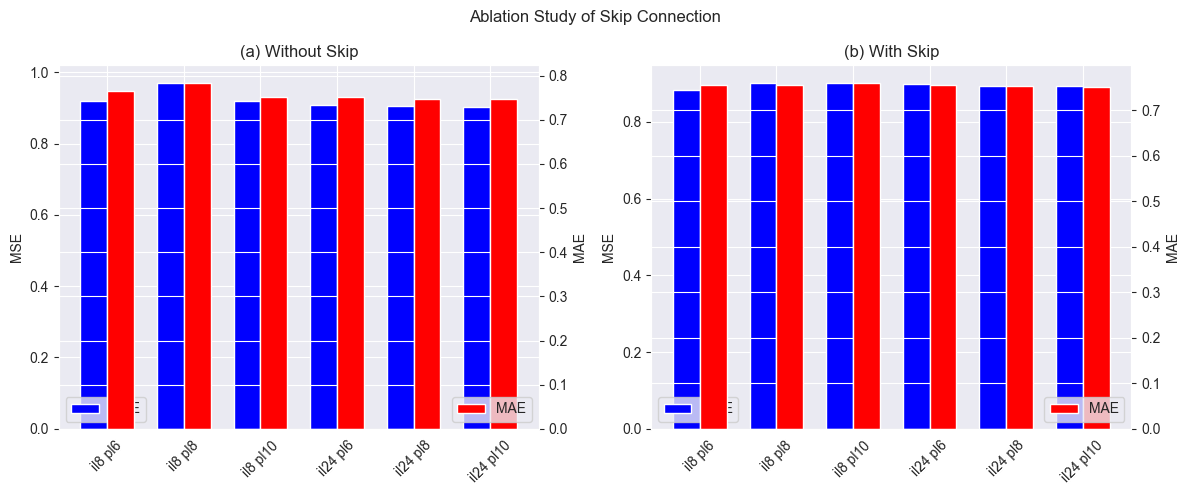

In [ ]:
plot_comparison(
    "Climate",
    "../../logs/wo_skip_connection.csv",
    "../../logs/prior_added_at_fusion/tff.csv",
)

In [ ]:
def plot_comparison_tgr(
    dataset_name, file_wo_skip, file_w_skip, experiments=[(8, 6), (8, 8), (8, 10)]
):

    # Load data
    df_without = pd.read_csv(file_wo_skip)
    df_with = pd.read_csv(file_w_skip)

    # Filter by dataset
    df_without = df_without[df_without["dataset"] == dataset_name]
    df_with = df_with[df_with["dataset"] == dataset_name]

    # Prepare data
    labels = [f"il{il} pl{pl}" for il, pl in experiments]
    without_mse = []
    without_mae = []
    with_mse = []
    with_mae = []

    for il, pl in experiments:
        row_without = df_without[
            (df_without["input_length"] == il) & (df_without["prediction_length"] == pl)
        ]
        row_with = df_with[
            (df_with["input_length"] == il) & (df_with["prediction_length"] == pl)
        ]

        without_mse.append(
            row_without["mse"].values[0] if not row_without.empty else np.nan
        )
        without_mae.append(
            row_without["mae"].values[0] if not row_without.empty else np.nan
        )
        with_mse.append(row_with["mse"].values[0] if not row_with.empty else np.nan)
        with_mae.append(row_with["mae"].values[0] if not row_with.empty else np.nan)

    # Plot
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))
    x = np.arange(len(labels))
    width = 0.35

    # MSE comparison
    axs.bar(
        x - width / 2,
        without_mse,
        width,
        label="Without Residual Connection",
        color="red",
    )
    axs.bar(
        x + width / 2, with_mse, width, label="With Residual Connection", color="pink"
    )
    axs.set_ylabel("MSE")
    axs.set_xticks(x)
    axs.set_xticklabels(labels, rotation=45)

    # Đặt legend ở phía dưới biểu đồ
    axs.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=2)

    plt.suptitle(f"{dataset_name} dataset")
    plt.tight_layout()
    plt.savefig(f"../paper/ablation_study_skip_connection_{dataset_name}.png")
    plt.show()

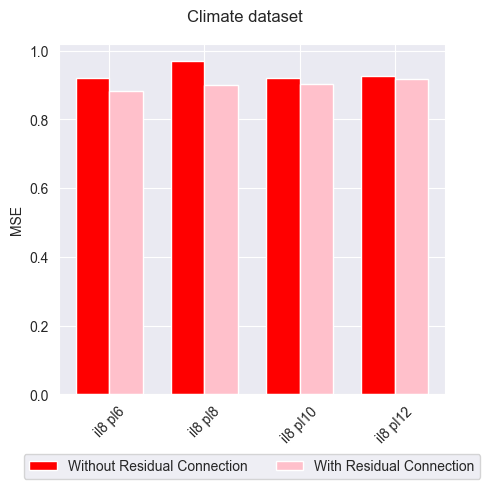

In [ ]:
plot_comparison_tgr(
    "Climate",
    "../../logs/wo_skip_connection.csv",
    "../../logs/prior_added_at_fusion/tff.csv",
    experiments=[(8, 6), (8, 8), (8, 10), (8, 12)],
)


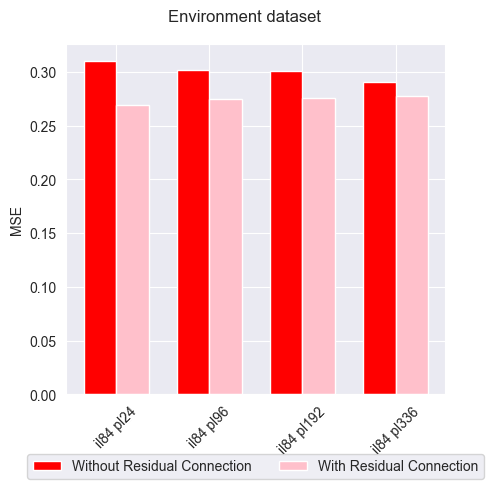

In [ ]:
plot_comparison_tgr(
    "Environment",
    "../../logs/wo_skip_connection.csv",
    "../../logs/prior_added_at_fusion/tff.csv",
    experiments=[(84, 24), (84, 96), (84, 192), (84, 336)],
)
